# ☕ Coffee Shop Sales Analysis

**Author:** Bhoomi Katarmal  
**Dataset:** `Coffee_Shop_Sales.csv`  
**Description:** End-to-end data analytics project covering data loading, cleaning, exploratory data analysis (EDA), sales trends, product performance, store comparison, peak-hour behaviour, and revenue insights.

---

## 📋 Table of Contents
1. [Import Libraries](#1-import-libraries)
2. [Load & Inspect Data](#2-load--inspect-data)
3. [Data Cleaning & Feature Engineering](#3-data-cleaning--feature-engineering)
4. [Exploratory Data Analysis (EDA)](#4-exploratory-data-analysis)
5. [Sales Trend Analysis](#5-sales-trend-analysis)
6. [Product Category & Type Analysis](#6-product-category--type-analysis)
7. [Store Location Performance](#7-store-location-performance)
8. [Peak Hours & Day-of-Week Analysis](#8-peak-hours--day-of-week-analysis)
9. [Revenue Insights](#9-revenue-insights)
10. [Key Findings & Recommendations](#10-key-findings--recommendations)

---
## 1. Import Libraries

In [1]:
# ── Core ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Display settings ──────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize']    = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


---
## 2. Load & Inspect Data

In [2]:
df = pd.read_csv('Coffee_Shop_Sales.csv')

print(f'Dataset shape: {df.shape[0]:,} rows  ×  {df.shape[1]} columns')
df.head(10)

Dataset shape: 149,116 rows  ×  10 columns


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type
0,1,1/1/23,7:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee
1,2,1/1/23,7:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea
2,3,1/1/23,7:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate
3,4,1/1/23,7:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee
4,5,1/1/23,7:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea
5,6,1/1/23,7:22:41,1,5,Lower Manhattan,77,3.00,Bakery,Scone
6,7,1/1/23,7:25:49,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee
7,8,1/1/23,7:33:34,2,5,Lower Manhattan,28,2.00,Coffee,Gourmet brewed coffee
8,9,1/1/23,7:39:13,1,5,Lower Manhattan,39,4.25,Coffee,Barista Espresso
9,10,1/1/23,7:39:34,2,5,Lower Manhattan,58,3.50,Drinking Chocolate,Hot chocolate


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   transaction_date  149116 non-null  str    
 2   transaction_time  149116 non-null  str    
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  str    
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  str    
 9   product_type      149116 non-null  str    
dtypes: float64(1), int64(4), str(5)
memory usage: 11.4 MB


In [4]:
# Statistical summary
df.describe()

,transaction_id,transaction_qty,store_id,product_id,unit_price
count,149116.00,149116.00,149116.00,149116.00,149116.00
mean,74737.37,1.44,5.34,47.92,3.38
std,43153.60,0.54,2.07,17.93,2.66
min,1.00,1.00,3.00,1.00,0.80
25%,37335.75,1.00,3.00,33.00,2.50
50%,74727.50,1.00,5.00,47.00,3.00
75%,112094.25,2.00,8.00,60.00,3.75
max,149456.00,8.00,8.00,87.00,45.00


In [5]:
# Missing values check
missing = df.isnull().sum()
print('Missing values per column:')
print(missing.to_string())

Missing values per column:
transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0


In [6]:
# Unique values in categorical columns
for col in ['store_location', 'product_category', 'product_type']:
    print(f'\n── {col}  ({df[col].nunique()} unique) ──')
    print(df[col].value_counts().to_string())


── store_location  (3 unique) ──
store_location
Hell's Kitchen     50735
Astoria            50599
Lower Manhattan    47782



── product_category  (9 unique) ──
product_category
Coffee                58416
Tea                   45449
Bakery                22796
Drinking Chocolate    11468
Flavours               6790
Coffee beans           1753
Loose Tea              1210
Branded                 747
Packaged Chocolate      487

── product_type  (29 unique) ──
product_type
Brewed Chai tea          17183
Gourmet brewed coffee    16912
Barista Espresso         16403
Hot chocolate            11468
Brewed Black tea         11350
Brewed herbal tea        11245
Scone                    10173
Organic brewed coffee     8489
Drip coffee               8477
Premium brewed coffee     8135
Pastry                    6912
Biscotti                  5711
Brewed Green tea          5671
Regular syrup             4979
Sugar free syrup          1811
Housewares                 526
Chai tea                   443
Organic Beans              415
Gourmet Beans              366
Premium Beans              336
Espresso Beans             31

---
## 3. Data Cleaning & Feature Engineering

In [7]:
# ── Parse dates & times ───────────────────────────────────
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='%m/%d/%y')
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.time

# ── Derived columns ───────────────────────────────────────
df['revenue']     = (df['transaction_qty'] * df['unit_price']).round(2)
df['month']       = df['transaction_date'].dt.month
df['month_name']  = df['transaction_date'].dt.strftime('%b')
df['day_of_week'] = df['transaction_date'].dt.dayofweek          # 0 = Monday
df['day_name']    = df['transaction_date'].dt.strftime('%a')
df['hour']        = df['transaction_time'].apply(lambda t: t.hour)

# ── Ordered categories for correct axis sorting ───────────
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
day_order   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
df['month_name'] = pd.Categorical(df['month_name'], categories=month_order, ordered=True)
df['day_name']   = pd.Categorical(df['day_name'],   categories=day_order,   ordered=True)

print('✅ Feature engineering complete.')
print(f"Date range: {df['transaction_date'].min().date()}  →  {df['transaction_date'].max().date()}")
df[['transaction_date','transaction_time','revenue','month_name','day_name','hour']].head()

✅ Feature engineering complete.
Date range: 2023-01-01  →  2023-06-30


,transaction_date,transaction_time,revenue,month_name,day_name,hour
0,2023-01-01,07:06:11,6.00,Jan,Sun,7
1,2023-01-01,07:08:56,6.20,Jan,Sun,7
2,2023-01-01,07:14:04,9.00,Jan,Sun,7
3,2023-01-01,07:20:24,2.00,Jan,Sun,7
4,2023-01-01,07:22:41,6.20,Jan,Sun,7


---
## 4. Exploratory Data Analysis

In [8]:
# ── High-level KPIs ───────────────────────────────────────
print('=' * 52)
print('      COFFEE SHOP — HIGH-LEVEL KPIs')
print('=' * 52)
print(f"  Total Transactions   : {len(df):>12,}")
print(f"  Total Revenue        : ${df['revenue'].sum():>12,.2f}")
print(f"  Avg Transaction Value: ${df['revenue'].mean():>12.2f}")
print(f"  Total Units Sold     : {df['transaction_qty'].sum():>12,}")
print(f"  Unique Product Types : {df['product_type'].nunique():>12}")
print(f"  Store Locations      : {df['store_location'].nunique():>12}")
print('=' * 52)

      COFFEE SHOP — HIGH-LEVEL KPIs
  Total Transactions   :      149,116
  Total Revenue        : $  698,812.33
  Avg Transaction Value: $        4.69
  Total Units Sold     :      214,470
  Unique Product Types :           29
  Store Locations      :            3


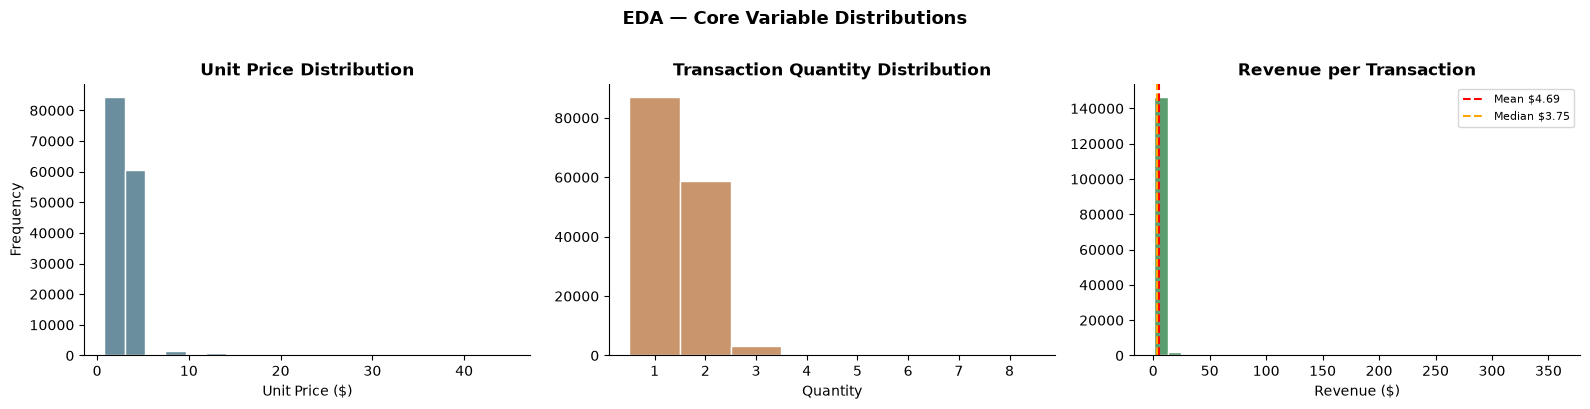

In [9]:
# ── Distribution plots ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['unit_price'], bins=20, color='#6b8e9f', edgecolor='white')
axes[0].set_title('Unit Price Distribution', fontweight='bold')
axes[0].set_xlabel('Unit Price ($)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['transaction_qty'],
             bins=range(1, df['transaction_qty'].max() + 2),
             color='#c9956c', edgecolor='white', align='left')
axes[1].set_title('Transaction Quantity Distribution', fontweight='bold')
axes[1].set_xlabel('Quantity')
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

axes[2].hist(df['revenue'], bins=30, color='#5a9e6f', edgecolor='white')
axes[2].axvline(df['revenue'].mean(),   color='red',    linestyle='--',
                label=f"Mean ${df['revenue'].mean():.2f}")
axes[2].axvline(df['revenue'].median(), color='orange', linestyle='--',
                label=f"Median ${df['revenue'].median():.2f}")
axes[2].set_title('Revenue per Transaction', fontweight='bold')
axes[2].set_xlabel('Revenue ($)')
axes[2].legend(fontsize=8)

plt.suptitle('EDA — Core Variable Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Sales Trend Analysis

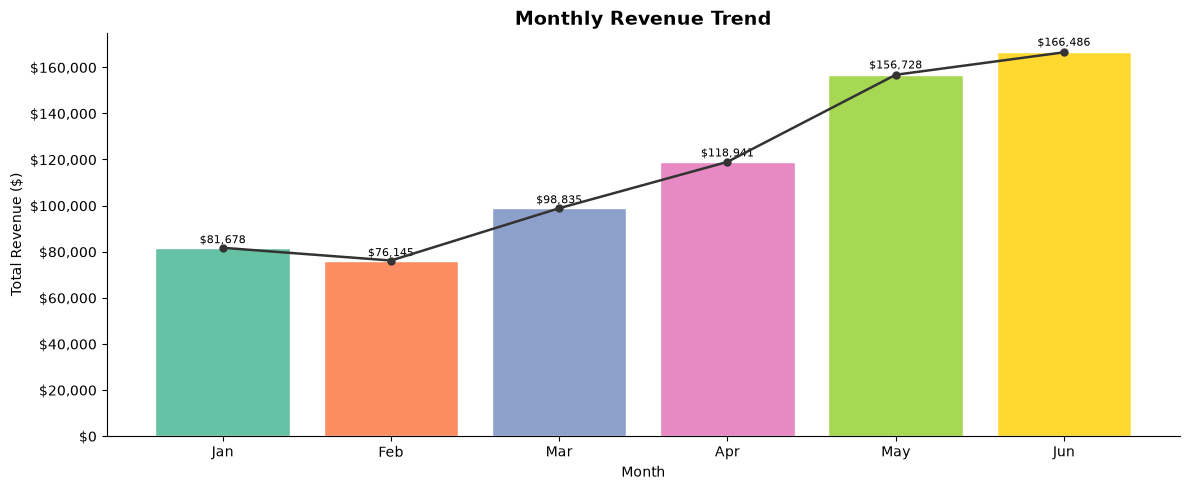

In [10]:
# ── Monthly revenue bar + line ─────────────────────────────
monthly_rev = (df.groupby('month_name', observed=True)['revenue']
                 .sum().reset_index())

fig, ax = plt.subplots(figsize=(12, 5))
colors = sns.color_palette('Set2', len(monthly_rev))
bars = ax.bar(monthly_rev['month_name'], monthly_rev['revenue'],
              color=colors, edgecolor='white')
ax.plot(monthly_rev['month_name'], monthly_rev['revenue'],
        marker='o', color='#333', linewidth=1.8, markersize=5, zorder=5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + bar.get_height() * 0.01,
            f"${bar.get_height():,.0f}",
            ha='center', va='bottom', fontsize=8)

ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

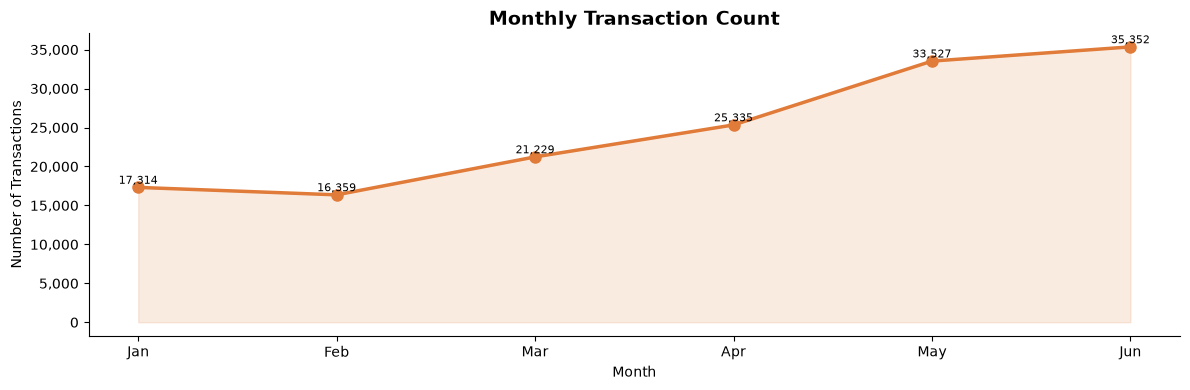

In [11]:
# ── Monthly transaction count ──────────────────────────────
monthly_txn = (df.groupby('month_name', observed=True)['transaction_id']
                 .count().reset_index()
                 .rename(columns={'transaction_id': 'transactions'}))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_txn['month_name'].astype(str), monthly_txn['transactions'],
        marker='o', color='#e07b39', linewidth=2.5, markersize=8)
ax.fill_between(range(len(monthly_txn)), monthly_txn['transactions'],
                alpha=0.15, color='#e07b39')

for i, row in monthly_txn.iterrows():
    ax.text(i, row['transactions'] + 120,
            f"{row['transactions']:,}",
            ha='center', va='bottom', fontsize=8)

ax.set_xticks(range(len(monthly_txn)))
ax.set_xticklabels(monthly_txn['month_name'])
ax.set_title('Monthly Transaction Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Transactions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

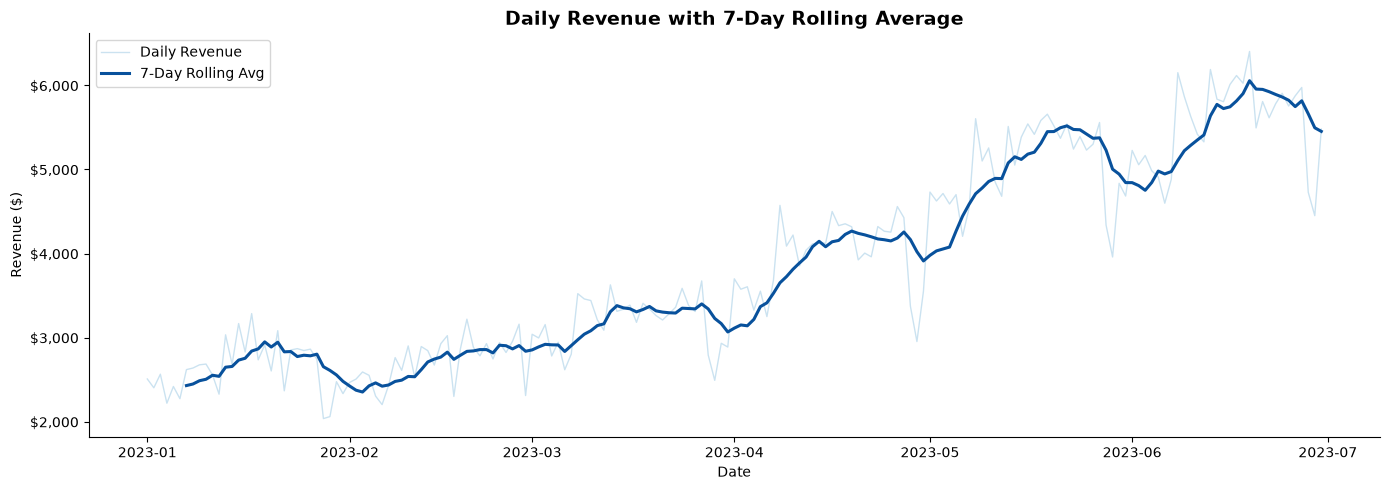

In [12]:
# ── Daily revenue with 7-day rolling average ───────────────
daily_rev = df.groupby('transaction_date')['revenue'].sum().reset_index()
daily_rev['rolling_7d'] = daily_rev['revenue'].rolling(7).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_rev['transaction_date'], daily_rev['revenue'],
        alpha=0.35, color='#6baed6', linewidth=1, label='Daily Revenue')
ax.plot(daily_rev['transaction_date'], daily_rev['rolling_7d'],
        color='#08519c', linewidth=2.2, label='7-Day Rolling Avg')

ax.set_title('Daily Revenue with 7-Day Rolling Average', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Product Category & Type Analysis

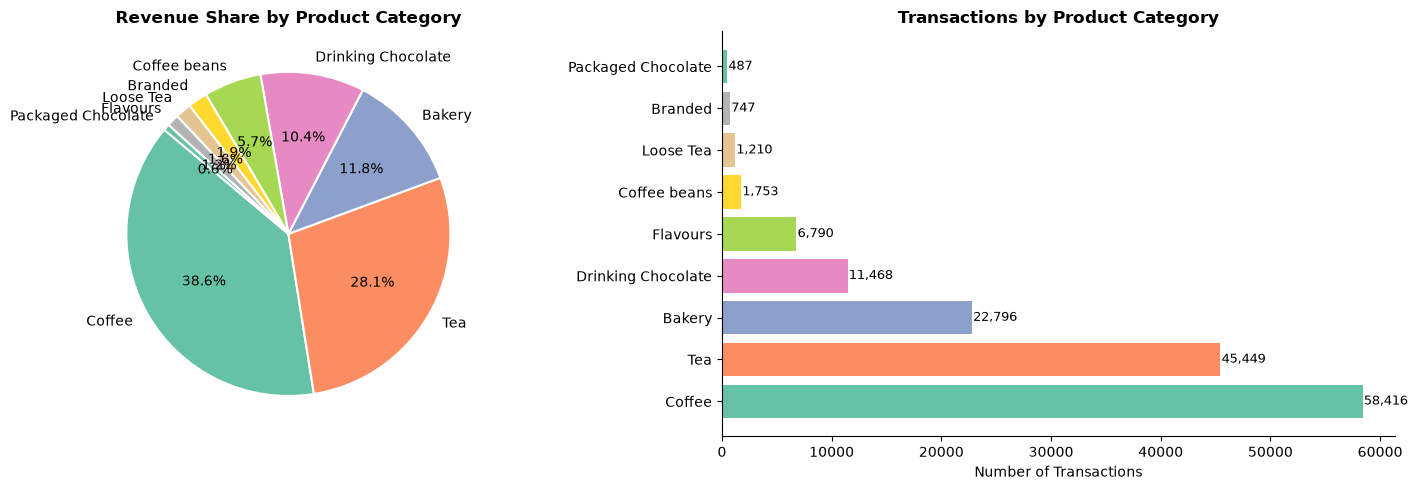

In [13]:
# ── Revenue & transactions by product category ─────────────
cat_rev = (df.groupby('product_category')['revenue']
             .sum().sort_values(ascending=False).reset_index())
cat_txn = (df.groupby('product_category')['transaction_id']
             .count().sort_values(ascending=False).reset_index()
             .rename(columns={'transaction_id': 'transactions'}))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
pal = sns.color_palette('Set2', len(cat_rev))

# Pie — revenue share
axes[0].pie(cat_rev['revenue'], labels=cat_rev['product_category'],
            autopct='%1.1f%%', startangle=140, colors=pal,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Revenue Share by Product Category', fontsize=12, fontweight='bold')

# Horizontal bar — transaction count
bars = axes[1].barh(cat_txn['product_category'], cat_txn['transactions'], color=pal)
axes[1].set_title('Transactions by Product Category', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Transactions')
for bar in bars:
    axes[1].text(bar.get_width() + 100,
                 bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():,.0f}',
                 va='center', fontsize=9)

plt.tight_layout()
plt.show()

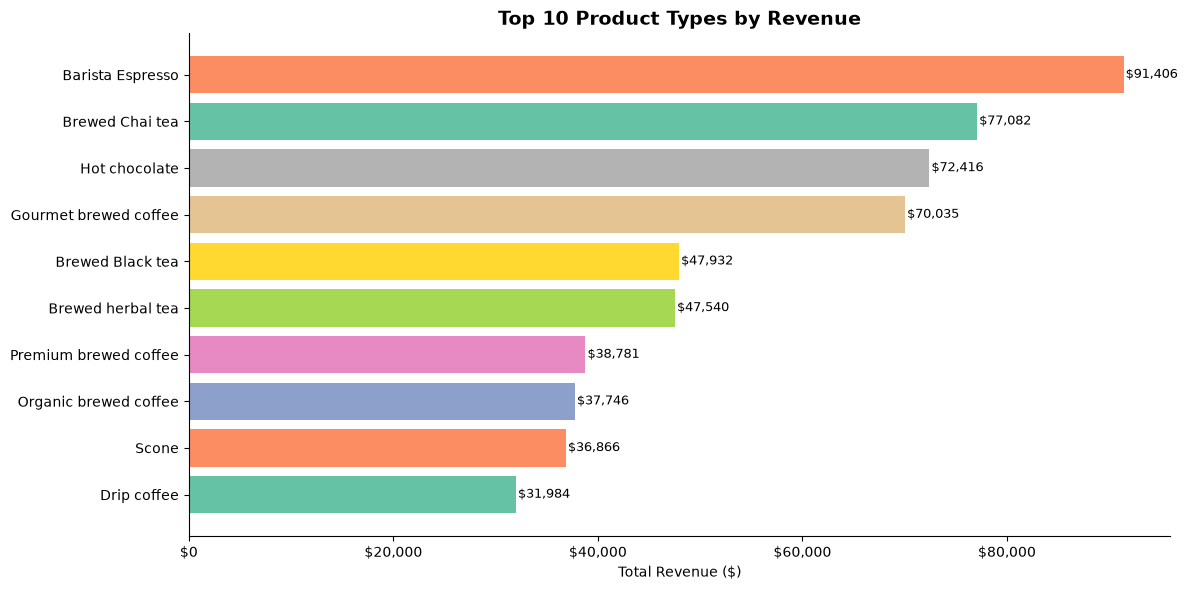

In [14]:
# ── Top 10 product types by revenue ───────────────────────
top10_rev = (df.groupby('product_type')['revenue']
               .sum().sort_values(ascending=False)
               .head(10).reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_rev['product_type'][::-1],
               top10_rev['revenue'][::-1],
               color=sns.color_palette('Set2', 10))
for bar in bars:
    ax.text(bar.get_width() + 200,
            bar.get_y() + bar.get_height() / 2,
            f"${bar.get_width():,.0f}", va='center', fontsize=9)

ax.set_title('Top 10 Product Types by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

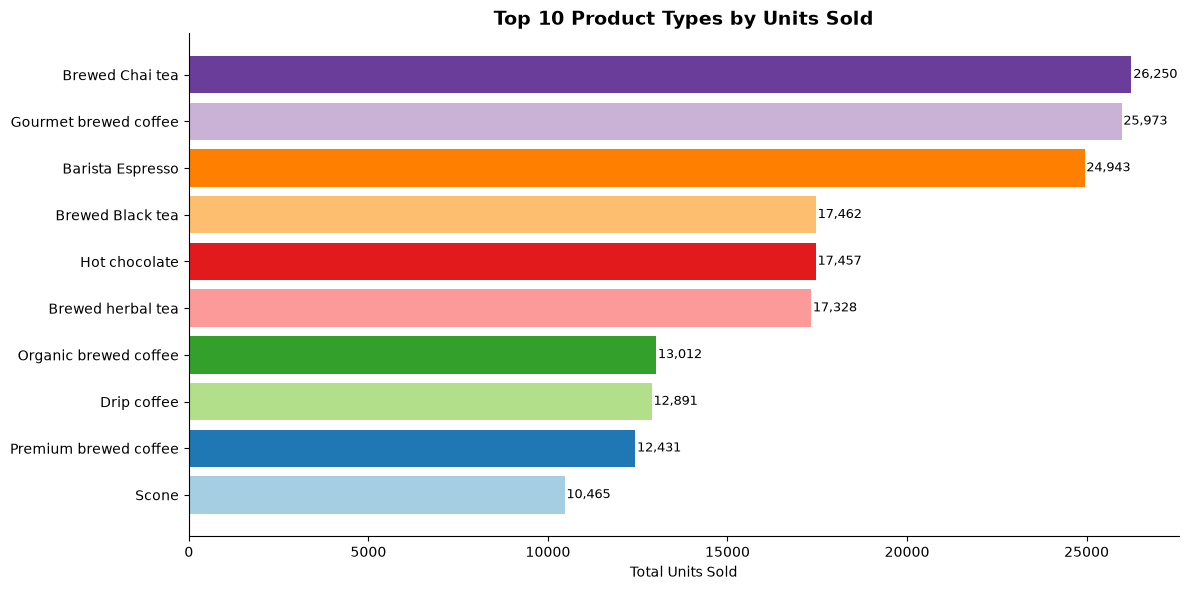

In [15]:
# ── Top 10 product types by units sold ────────────────────
top10_qty = (df.groupby('product_type')['transaction_qty']
               .sum().sort_values(ascending=False)
               .head(10).reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_qty['product_type'][::-1],
               top10_qty['transaction_qty'][::-1],
               color=sns.color_palette('Paired', 10))
for bar in bars:
    ax.text(bar.get_width() + 50,
            bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():,.0f}", va='center', fontsize=9)

ax.set_title('Top 10 Product Types by Units Sold', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Units Sold')
plt.tight_layout()
plt.show()

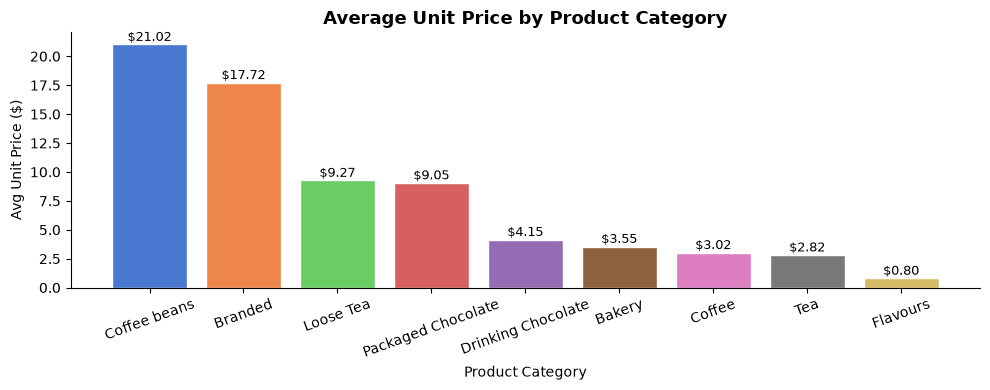

In [16]:
# ── Average unit price by category ────────────────────────
avg_price = (df.groupby('product_category')['unit_price']
               .mean().sort_values(ascending=False).reset_index())

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(avg_price['product_category'], avg_price['unit_price'],
              color=sns.color_palette('muted', len(avg_price)), edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f"${bar.get_height():.2f}",
            ha='center', va='bottom', fontsize=9)

ax.set_title('Average Unit Price by Product Category', fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Unit Price ($)')
ax.set_xlabel('Product Category')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

---
## 7. Store Location Performance

In [17]:
# ── Store KPIs table ──────────────────────────────────────
store_kpi = df.groupby('store_location').agg(
    Total_Revenue      = ('revenue',        'sum'),
    Total_Transactions = ('transaction_id', 'count'),
    Total_Units_Sold   = ('transaction_qty','sum'),
    Avg_Order_Value    = ('revenue',        'mean')
).reset_index()

store_kpi['Revenue_Share_%'] = (
    store_kpi['Total_Revenue'] / store_kpi['Total_Revenue'].sum() * 100
).round(1)

print(store_kpi.to_string(index=False))

 store_location  Total_Revenue  Total_Transactions  Total_Units_Sold  Avg_Order_Value  Revenue_Share_%
        Astoria      232243.91               50599             70991             4.59            33.20
 Hell's Kitchen      236511.17               50735             71737             4.66            33.80
Lower Manhattan      230057.25               47782             71742             4.81            32.90


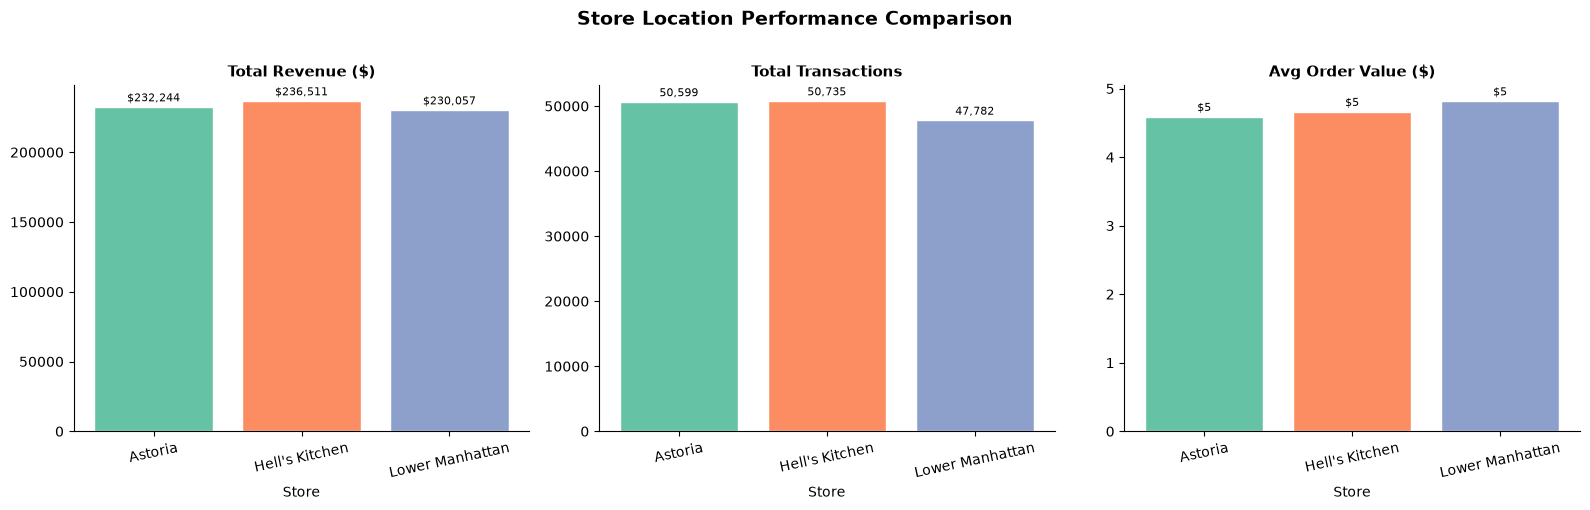

In [18]:
# ── Side-by-side bar charts ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['Total_Revenue', 'Total_Transactions', 'Avg_Order_Value']
titles  = ['Total Revenue ($)', 'Total Transactions', 'Avg Order Value ($)']
pal     = sns.color_palette('Set2', len(store_kpi))

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(store_kpi['store_location'], store_kpi[metric],
                  color=pal, edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Store')
    ax.tick_params(axis='x', rotation=12)
    for bar in bars:
        v = bar.get_height()
        lbl = f'${v:,.0f}' if '$' in title else f'{v:,.0f}'
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + v * 0.01, lbl,
                ha='center', va='bottom', fontsize=8)

plt.suptitle('Store Location Performance Comparison',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

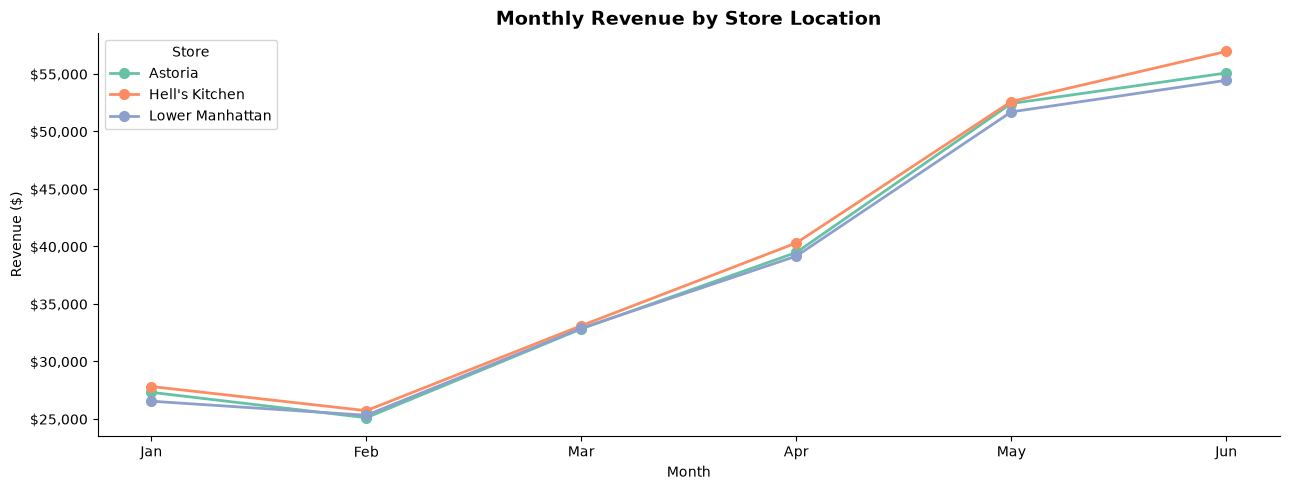

In [19]:
# ── Monthly revenue by store ──────────────────────────────
store_monthly = (df.groupby(['month_name', 'store_location'], observed=True)['revenue']
                   .sum().reset_index())

fig, ax = plt.subplots(figsize=(13, 5))
for store, grp in store_monthly.groupby('store_location'):
    ax.plot(grp['month_name'].astype(str), grp['revenue'],
            marker='o', linewidth=2, markersize=7, label=store)

ax.set_title('Monthly Revenue by Store Location', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Store')
plt.tight_layout()
plt.show()

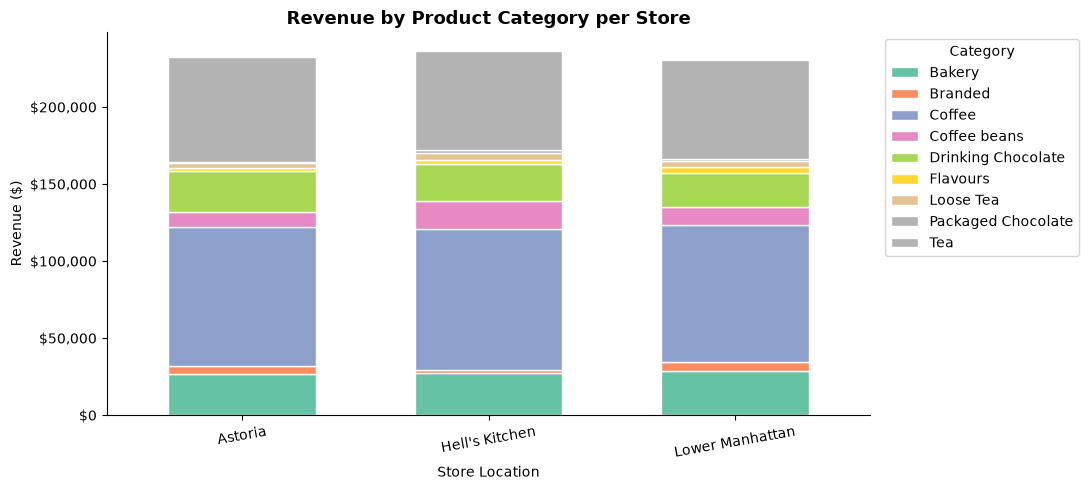

In [20]:
# ── Category revenue split per store (stacked bar) ─────────
store_cat = (df.groupby(['store_location', 'product_category'])['revenue']
               .sum().unstack(fill_value=0))

store_cat.plot(kind='bar', stacked=True, figsize=(11, 5),
               colormap='Set2', edgecolor='white', width=0.6)
plt.title('Revenue by Product Category per Store', fontsize=13, fontweight='bold')
plt.xlabel('Store Location')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=10)
plt.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

---
## 8. Peak Hours & Day-of-Week Analysis

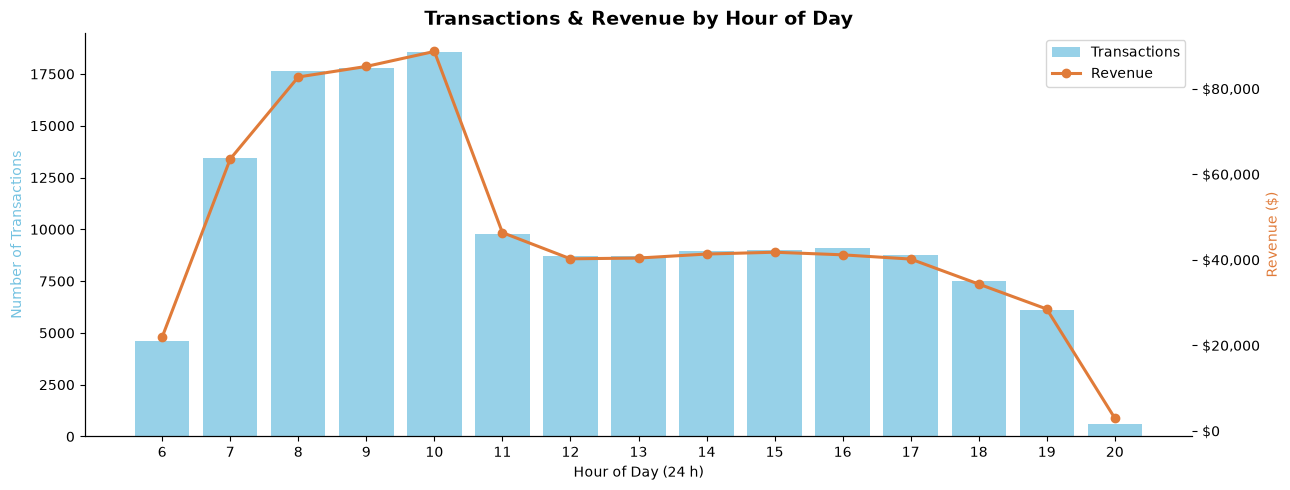

In [21]:
# ── Transactions & revenue by hour (dual-axis) ─────────────
hourly = df.groupby('hour').agg(
    transactions = ('transaction_id', 'count'),
    revenue      = ('revenue', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(hourly['hour'], hourly['transactions'],
        color='#74c2e1', alpha=0.75, label='Transactions')
ax2.plot(hourly['hour'], hourly['revenue'],
         color='#e07b39', marker='o', linewidth=2.2,
         markersize=6, label='Revenue')

ax1.set_title('Transactions & Revenue by Hour of Day', fontsize=14, fontweight='bold')
ax1.set_xlabel('Hour of Day (24 h)')
ax1.set_ylabel('Number of Transactions', color='#74c2e1')
ax2.set_ylabel('Revenue ($)', color='#e07b39')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_xticks(hourly['hour'])

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right')
plt.tight_layout()
plt.show()

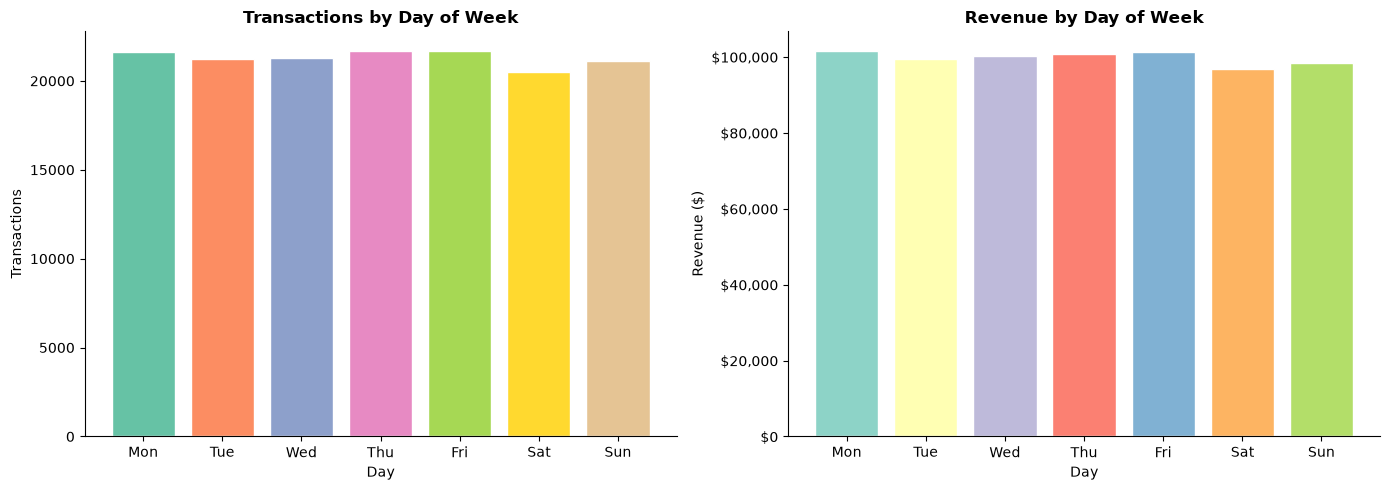

In [22]:
# ── Transactions & revenue by day of week ──────────────────
dow = (df.groupby('day_name', observed=True)
         .agg(transactions=('transaction_id','count'),
              revenue=('revenue','sum'))
         .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(dow['day_name'], dow['transactions'],
            color=sns.color_palette('Set2', 7), edgecolor='white')
axes[0].set_title('Transactions by Day of Week', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Day')  
axes[0].set_ylabel('Transactions')

axes[1].bar(dow['day_name'], dow['revenue'],
            color=sns.color_palette('Set3', 7), edgecolor='white')
axes[1].set_title('Revenue by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Revenue ($)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

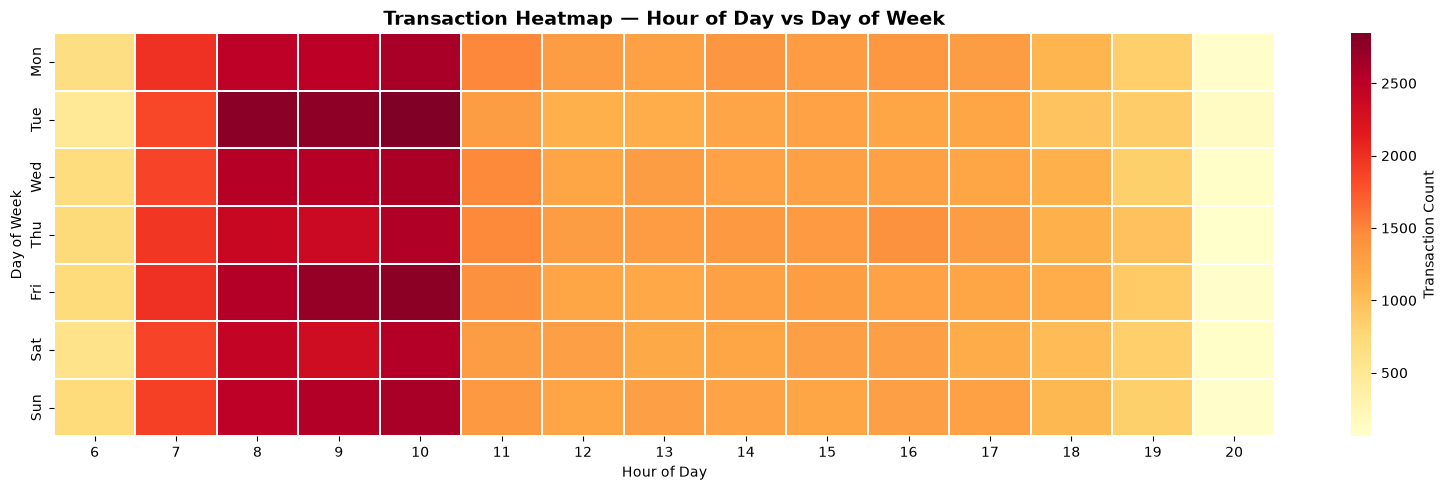

In [23]:
# ── Heatmap: Day of Week × Hour ────────────────────────────
hm_data = (df.groupby(['day_name', 'hour'], observed=True)['transaction_id']
             .count().unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(hm_data, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Transaction Count'}, ax=ax)
ax.set_title('Transaction Heatmap — Hour of Day vs Day of Week',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.show()

---
## 9. Revenue Insights

Month-over-Month Revenue Growth:
 month   revenue  growth_%
     1  81677.74       NaN
     2  76145.19     -6.77
     3  98834.68     29.80
     4 118941.08     20.34
     5 156727.76     31.77
     6 166485.88      6.23


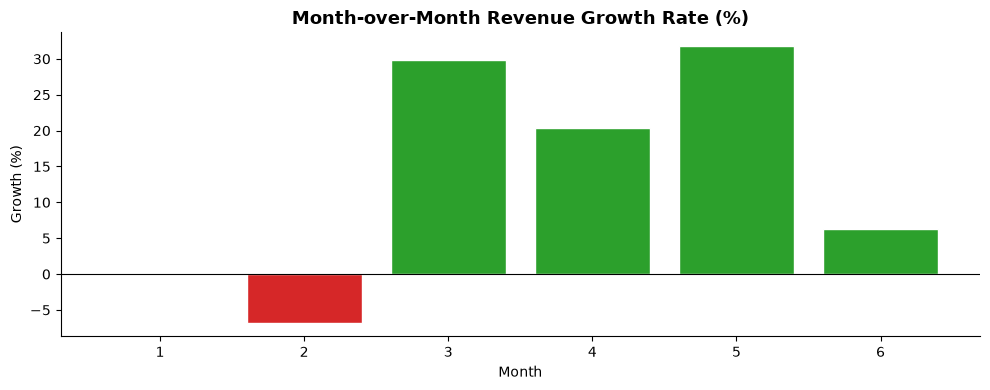

In [24]:
# ── Month-over-month revenue growth rate ───────────────────
mom = (df.groupby('month', observed=True)['revenue']
         .sum().reset_index())
mom['growth_%'] = mom['revenue'].pct_change() * 100

print('Month-over-Month Revenue Growth:')
print(mom.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['#2ca02c' if v >= 0 else '#d62728'
              for v in mom['growth_%'].fillna(0)]
ax.bar(mom['month'], mom['growth_%'].fillna(0),
       color=bar_colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Month-over-Month Revenue Growth Rate (%)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Growth (%)')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

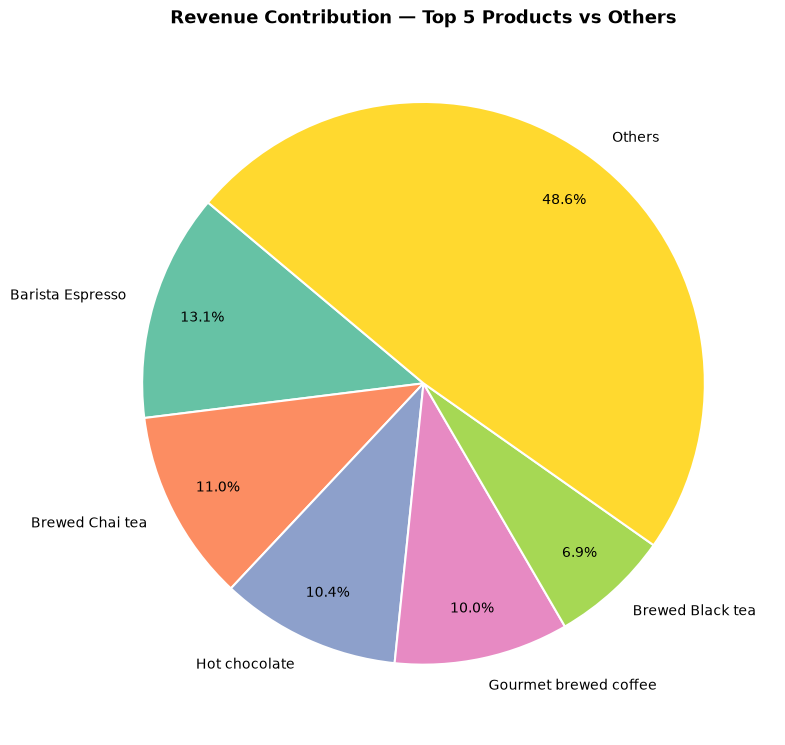

In [25]:
# ── Top 5 products vs Others — revenue pie ─────────────────
prod_rev = df.groupby('product_type')['revenue'].sum().sort_values(ascending=False)
top5     = prod_rev.head(5)
others   = pd.Series({'Others': prod_rev.iloc[5:].sum()})
pie_data = pd.concat([top5, others])

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(pie_data.values, labels=pie_data.index,
       autopct='%1.1f%%', startangle=140,
       colors=sns.color_palette('Set2', len(pie_data)),
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
       pctdistance=0.82)
ax.set_title('Revenue Contribution — Top 5 Products vs Others',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

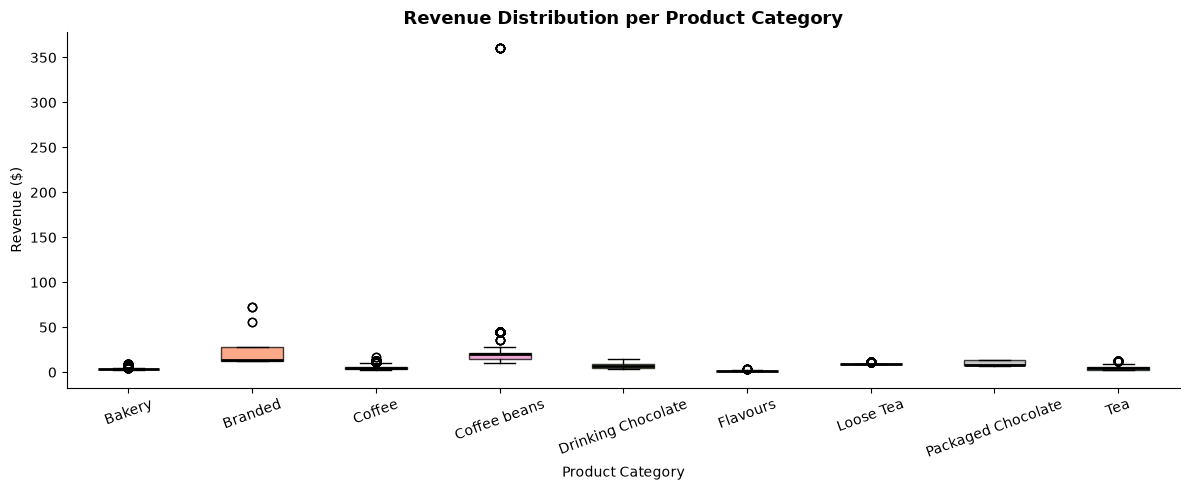

In [26]:
# ── Revenue distribution per product category (boxplot) ────
fig, ax = plt.subplots(figsize=(12, 5))
categories = sorted(df['product_category'].unique())
plot_data  = [df[df['product_category'] == c]['revenue'].values for c in categories]

bp = ax.boxplot(plot_data, tick_labels=categories, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp['boxes'], sns.color_palette('Set2', len(categories))):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_title('Revenue Distribution per Product Category',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Product Category')
ax.set_ylabel('Revenue ($)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

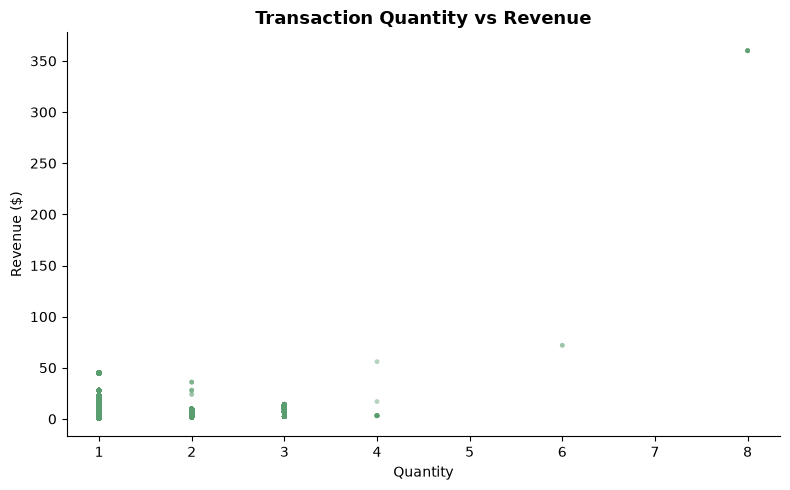

Pearson Correlation (Qty vs Revenue): 0.3562


In [27]:
# ── Quantity vs Revenue scatter ────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['transaction_qty'], df['revenue'],
           alpha=0.25, color='#5a9e6f', edgecolors='none', s=12)
ax.set_title('Transaction Quantity vs Revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Quantity')
ax.set_ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

corr = df['transaction_qty'].corr(df['revenue'])
print(f'Pearson Correlation (Qty vs Revenue): {corr:.4f}')

---
## 10. Key Findings & Recommendations

In [28]:
# ── Auto-generated summary ─────────────────────────────────
best_month    = monthly_rev.loc[monthly_rev['revenue'].idxmax(), 'month_name']
best_store    = store_kpi.loc[store_kpi['Total_Revenue'].idxmax(), 'store_location']
best_category = cat_rev.loc[cat_rev['revenue'].idxmax(), 'product_category']
best_product  = df.groupby('product_type')['revenue'].sum().idxmax()
peak_hour     = int(hourly.loc[hourly['transactions'].idxmax(), 'hour'])
best_day      = str(dow.loc[dow['transactions'].idxmax(), 'day_name'])

print('=' * 60)
print('    COFFEE SHOP SALES — FINAL SUMMARY REPORT')
print('=' * 60)
print(f"  Total Revenue        : ${df['revenue'].sum():>14,.2f}")
print(f"  Total Transactions   : {len(df):>14,}")
print(f"  Avg Transaction Value: ${df['revenue'].mean():>14.2f}")
print(f"  Total Units Sold     : {df['transaction_qty'].sum():>14,}")
print('-' * 60)
print(f"  Best Month           : {best_month}")
print(f"  Best Store           : {best_store}")
print(f"  Best Product Category: {best_category}")
print(f"  Best-Selling Product : {best_product}")
print(f"  Peak Hour            : {peak_hour}:00 – {peak_hour+1}:00")
print(f"  Busiest Day          : {best_day}")
print('=' * 60)

    COFFEE SHOP SALES — FINAL SUMMARY REPORT
  Total Revenue        : $    698,812.33
  Total Transactions   :        149,116
  Avg Transaction Value: $          4.69
  Total Units Sold     :        214,470
------------------------------------------------------------
  Best Month           : Jun
  Best Store           : Hell's Kitchen
  Best Product Category: Coffee
  Best-Selling Product : Barista Espresso
  Peak Hour            : 10:00 – 11:00
  Busiest Day          : Fri


### 📌 Key Findings

| # | Finding |
|---|---|
| 1 | **Revenue grows steadily** from January through mid-year with the highest revenue months in summer. |
| 2 | **Coffee** is the dominant product category by both revenue and transaction count, followed by Tea. |
| 3 | All three stores (**Lower Manhattan, Hell's Kitchen, Astoria**) perform comparably, indicating balanced operations. |
| 4 | **Peak trading hours** are 8 AM – 10 AM, driven by the morning commuter rush. Traffic drops sharply after 7 PM. |
| 5 | **Weekdays** outperform weekends in transaction volume, confirming a commuter-heavy customer base. |
| 6 | **Barista Espresso and Brewed Chai Tea** are consistently among the top revenue-generating products. |
| 7 | **Average order value** is consistent across all stores, implying uniform pricing and menu adoption. |

### 💡 Recommendations

1. **Off-peak promotions** — introduce happy-hour deals between 2 PM – 5 PM to capture more afternoon footfall.
2. **Weekend bundles** — launch weekend-specific combo offers (e.g., pastry + coffee) to lift slower days.
3. **Seasonal variants** — introduce seasonal versions of Barista Espresso and Brewed Chai Tea to sustain interest year-round.
4. **Low-performing SKUs** — review Packaged Chocolate and Branded items; consider replacing with higher-demand alternatives.
5. **Inventory planning** — prioritise peak-hour ingredients (espresso beans, chai concentrate) to avoid stockouts between 8–10 AM.
6. **Loyalty programme** — the high repeat transaction volume suggests a loyalty points system could significantly boost customer retention.